In [1]:
pip install requests beautifulsoup4 pandas matplotlib selenium

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 2.6 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.6 MB 2.9 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.6 MB 3.2 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.6 MB 3.3 MB/s eta 0:00:02
   ----------------- ---------------------- 4.2/9.6 MB 3.5 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 3.5 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.6 MB 3.6 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.6 MB 3.6 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.6 MB 3.6 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.6 MB 3.6 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 3.7 MB/s eta 0:00:01
   -----------------------

Kütüphaneler başarıyla yüklendi.
Başarıyla çekilen başlık sayısı: 3
--- Kritik Seviyedeki Veriler ---


,Kaynak,Kategori,Onem_Derecesi,Islem_Sayisi
0,Savunma_Bulteni,Donanım,8,120
1,OSINT_Raporu,İstihbarat,9,450
4,Saha_Gozlem,Taktik,10,310


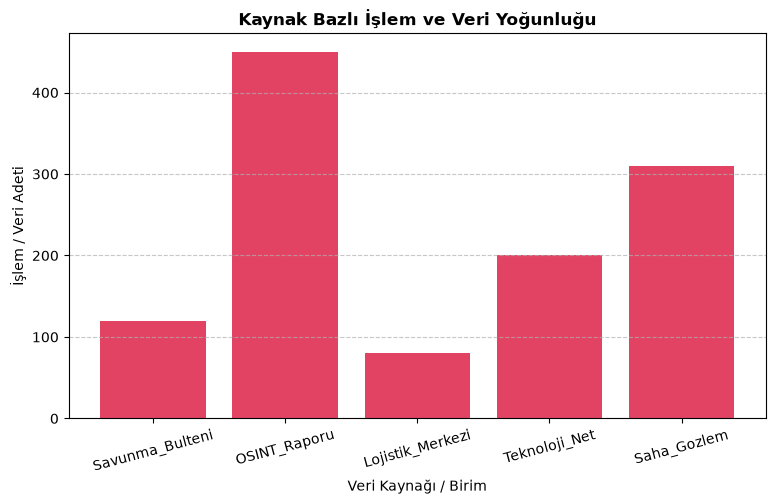

In [2]:
# %% [markdown]
# ## 1. Kütüphanelerin Yüklenmesi
# Veri çekme, işleme ve görselleştirme için gerekli kütüphaneler içe aktarılır.

# %%
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
import time

print("Kütüphaneler başarıyla yüklendi.")

# %% [markdown]
# ## 2. BeautifulSoup ile Statik Veri Çekme (Web Scraping)
# Açık kaynaklı savunma haberleri veya bültenlerinden başlık/veri toplama simülasyonu.

# %%
url = "https://www.defensenews.com"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}

haber_listesi = []

try:
    response = requests.get(url, headers=headers, timeout=10)
    if response.status_code == 200:
        soup = BeautifulSoup(response.content, "html.parser")
        
        # Sitedeki başlık etiketlerini çekme
        elements = soup.find_all("h3")
        for el in elements:
            text = el.get_text(strip=True)
            if len(text) > 5: # Boş veya çok kısa başlıkları ele
                haber_listesi.append(text)
                
        print(f"Başarıyla çekilen başlık sayısı: {len(haber_listesi)}")
    else:
        print(f"Hata Kodu: {response.status_code}")
except Exception as e:
    print(f"Bağlantı sırasında hata oluştu: {e}")

# %% [markdown]
# ## 3. Selenium ile Dinamik Sayfalardan Veri Çekme
# JavaScript ile yüklenen veya buton etkileşimi gerektiren sayfalar için tarayıcı otomasyonu.

# %%
def selenium_veri_cek(hedef_url):
    options = Options()
    options.add_argument("--headless") # Arayüzü açmadan arka planda çalıştırır
    options.add_argument("--disable-gpu")
    
    driver = webdriver.Chrome(options=options)
    dinamik_veriler = []
    
    try:
        driver.get(hedef_url)
        time.sleep(3) # Sayfanın yüklenmesi için bekleme
        
        # Sayfadaki tüm linkleri veya metinleri toplama
        linkler = driver.find_elements(By.TAG_NAME, "a")
        for l in linkler:
            metin = l.text.strip()
            if metin and len(metin) > 10:
                dinamik_veriler.append(metin)
                
    except Exception as e:
        print(f"Selenium hatası: {e}")
    finally:
        driver.quit()
        
    return dinamik_veriler

# Örnek kullanım (Test URL'si yerine hedef site yazılabilir)
# site_verileri = selenium_veri_cek("https://www.ssb.gov.tr")
# print(f"Dinamik çekilen veri sayısı: {len(site_verileri)}")

# %% [markdown]
# ## 4. Pandas ile Veri Analizi ve Temizleme
# Çekilen metin verilerini veya simüle edilmiş lojistik/istihbarat verilerini işleme.

# %%
# Örnek bir stratejik veri seti oluşturalım (Çekilen verilerin analizi için)
data = {
    'Kaynak': ['Savunma_Bulteni', 'OSINT_Raporu', 'Lojistik_Merkezi', 'Teknoloji_Net', 'Saha_Gozlem'],
    'Kategori': ['Donanım', 'İstihbarat', 'İkmal', 'Ar-Ge', 'Taktik'],
    'Onem_Derecesi': [8, 9, 6, 7, 10],
    'Islem_Sayisi': [120, 450, 80, 200, 310]
}

df = Dataframe = pd.DataFrame(data)

# Önem derecesine göre filtreleme (Kritik durumlar)
kritik_veriler = df[df['Onem_Derecesi'] >= 8]
print("--- Kritik Seviyedeki Veriler ---")
display(kritik_veriler)

# %% [markdown]
# ## 5. Matplotlib ile Görselleştirme
# Analiz edilen verilerin grafik olarak Jupyter içinde sunulması.

# %%
plt.figure(figsize=(9, 5))
plt.bar(df['Kaynak'], df['Islem_Sayisi'], color='crimson', alpha=0.8)

plt.title("Kaynak Bazlı İşlem ve Veri Yoğunluğu", fontsize=12, fontweight='bold')
plt.xlabel("Veri Kaynağı / Birim")
plt.ylabel("İşlem / Veri Adeti")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=15)
plt.show()